# Task 2: CNN Training for pixel-wise classification

In this task you will be provided a model that was pretrained on [BigEarthNet v2](https://arxiv.org/abs/1902.06148) for pixel-wise classification (i.e. semantic segmentation). We will provide you with a checkpoint, as well as the model definition and your task is to load that model using these weights and finetune it on our target domain (forest segmentation) in our target location (Amazon Rainforest) with pytorch lightning. For that we will provide you with a finetuning dataset.

<img src="../../../data/Example_finetune.png" alt="Example from Dataset" width="600"/>


The goals of this task are as follows:
1. Load a pretrained pixelwise segmentation model
2. Adapt and finetune the model on a new domain (forest segmentation) and location (Amazon Rain Forest)

## Imports

These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [2]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)


In [1]:
import torch
from types import SimpleNamespace
from huggingface_hub import PyTorchModelHubMixin
import lightning as L
from configilm import ConfigILM # see https://lhackel-tub.github.io/ConfigILM/ for more information
from torchinfo import summary

from torchmetrics.segmentation import MeanIoU
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF

import lmdb
from torch.utils.data import Dataset, DataLoader, random_split
from safetensors.numpy import load as load_np_safetensor
import torchvision.transforms as transforms

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import random

from lightning.pytorch import Trainer
from torch.utils.data import Subset
import numpy as np

In [3]:
# Additionally, import util functions that where copied from the lab notebooks
import labUtils as labUtils

## 2.1 Dataset + DataModule definition

Before we can use our data we need to wrap it in a pytorch dataset and thereafter in a lightning DataModule so we can use it for model training. 

### Dataset

For efficient data loading we have put the images in the file `images.lmdb` and the segmentation masks (forest/ no forest) in the file `mask.lmdb`. [LMDB](http://www.lmdb.tech/doc/) is a key-value in-memory database. For the images the key is the image name (1.tif, 2.tif,...) and the values are the image pixels as safetensor (Tip: use `load_np_safetensor` to read it). For the masks the key is the image name followed by _mask (1_mask.tif, 2_mask.tif, ...) the value again is the pixels as safetensor (1 for forest, 0 for no forest). We provided the helper function `_open_lmdb` which opens a connection to the lmdb for images or masks if it does not exist yet. You can read data from the lmdb through `with self.env_images.begin() as txn: txn.get()`. Feel free to add additional functions and adapt the already existing ones. Please open the lmdb only in the `__getitem__` method, due to multi processing.
Use preprocessing and data augmentation where applicable.

In [12]:
mean =  [438.37207031, 614.05566406, 588.40960693, 2193.29199219, 942.84332275, 1769.93164062, 2049.55151367, 1568.22680664, 997.73248291, 2235.55664062]
std = [607.02685547, 603.29681396, 684.56884766, 1369.3717041, 738.43267822, 1100.45605469, 1275.80541992, 1070.16125488, 813.52764893, 1356.54406738]

image_transform_normalize = transforms.Compose(
    [
        transforms.ToTensor(), 
        transforms.Normalize(mean=mean, std=std),
    ]
)


class FinetuneDataset(Dataset):
    def __init__(self, images_lmdb_path=data_path / "images.lmdb", masks_lmdb_path=data_path / "mask.lmdb", image_transform=None):
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path

        self.image_transform = image_transform

        self.env_images = self._open_lmdb(None, str(self.images_lmdb_path))
        self.env_masks = self._open_lmdb(None, str(self.masks_lmdb_path))

        with self.env_images.begin() as txn:
            self.length = txn.stat()['entries']


    def _open_lmdb(self, env, path):
        # If the environment is already opened, simply return it
        if env is not None:
            return env
    
        # The path must be a nonempty string
        if not path:
            raise ValueError("The LMDB path is not set")
    
        # Attempt to open the environment; if it fails, rewrap the exception
        try:
            return lmdb.open(path, readonly=True, lock=False)
        except lmdb.Error as e:
            raise RuntimeError(f"Failed to open LMDB at {path!r}") from e


    def _get_image_keys(self):
        with self.env_images.begin() as txn:
            cursor = txn.cursor()
            return [key.decode() for key, _ in cursor]
        
    
    def _get_mask_keys(self):
        with self.env_masks.begin() as txn:
            cursor = txn.cursor()
            return [key.decode() for key, _ in cursor]
        

    def __len__(self):
        return self.length


    def __getitem__(self, idx):
        key_image = str(f"{idx}.tif").encode()
        key_mask = str(f"{idx}_mask.tif").encode()

        with self.env_images.begin() as img_txn:
            img_bytes = img_txn.get(key_image)
            if img_bytes is None:
                raise KeyError(f"Image not found at index {idx}")
            image = load_np_safetensor(img_bytes)["data"]

        with self.env_masks.begin() as mask_txn:
            mask_bytes = mask_txn.get(key_mask)
            if mask_bytes is None:
                raise KeyError(f"Mask not found at index {idx}")
            mask = load_np_safetensor(mask_bytes)["data"]

        image = image.astype(np.float32)
        #mask = mask.astype(np.float32).squeeze()
        mask = torch.tensor(mask, dtype=torch.float32)

        # Convert image from (C, H, W) numpy array to (H, W, C) for ToTensor
        image = np.transpose(image, (1, 2, 0))  # now (120, 120, 10)

        if self.image_transform:
            image = self.image_transform(image)  # expects numpy HWC → tensor CHW

        return image, mask

dataset has length of: 5852
image and mask shapes
torch.Size([10, 120, 120])
torch.Size([1, 120, 120])
-0.6498547792434692 4.07271671295166 1.406730055809021 0.8066225051879883


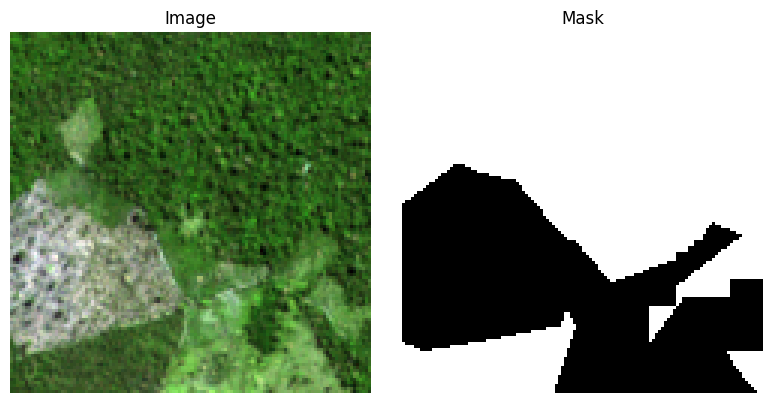

In [15]:
# Util plot function
def show_image_and_mask(image, mask):

    image = image.cpu().numpy()
    mask = mask.cpu().numpy().squeeze()

    if image.dtype == 'object':
        image = image.astype(np.uint8)
    if mask.dtype == 'object':
        mask = mask.astype(np.uint8)

    rgb = image[np.array((0, 1, 2)), :, :].astype(np.float32)
    eps = 1e-6
    for i in range(rgb.shape[0]):
        rgb[i] = (rgb[i] - rgb[i].min()) / (rgb[i].max() - rgb[i].min() + eps)

    rgb = np.transpose(rgb, (1, 2, 0))
    #mask = np.transpose(mask, (1, 2, 0))

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ------------------
# Testing the Dataset 

dataset = FinetuneDataset(
    images_lmdb_path = data_path / "images.lmdb",
    masks_lmdb_path = data_path / "mask.lmdb",
    image_transform=image_transform_normalize
)

print(f"dataset has length of: {dataset.length}")

# inspecting the dataset a little bit
image, mask = dataset[120]
print("image and mask shapes")
print(np.shape(image))
print(np.shape(mask))

# check normalization
print(image.min().item(), image.max().item(), image.mean().item(), image.std().item())

show_image_and_mask(image, mask)

### DataModule

Your DataModule needs to return a valid dataloader for training, validation and testing. Implement the [pytorch lighting](https://lightning.ai/docs/pytorch/stable/) training procedure.

In [26]:
class FinetuneDataModule(L.LightningDataModule):
    def __init__(
        self,
        images_lmdb_path= data_path / "images.lmdb",
        masks_lmdb_path= data_path / "mask.lmdb",
        batch_size=16,
        num_workers=0,
        image_transform=image_transform_normalize,
    ):
        super().__init__()
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.image_transform = image_transform

    def setup(self, stage=None):
        full_dataset = FinetuneDataset(
            images_lmdb_path=self.images_lmdb_path,
            masks_lmdb_path=self.masks_lmdb_path,
            image_transform=self.image_transform
        )

        # Shuffle indices
        indices = list(range(len(full_dataset)))
        random.seed(22)
        random.shuffle(indices)

        # ATM I split the dataset fixed into the typical train 80%, val 10% and tes 10%
        train_end = int(0.8 * len(indices))
        val_end = int(0.9 * len(indices))

        self.train_set = Subset(full_dataset, indices[:train_end])
        self.val_set = Subset(full_dataset, indices[train_end:val_end])
        self.test_set = Subset(full_dataset, indices[val_end:])

        print("--- dataloader overview ---")
        print(f"len train set: {len(self.train_set)}")
        print(f"len val set: {len(self.val_set)}")
        print(f"len test set: {len(self.test_set)}")


    def train_dataloader(self):
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

## 2.2 Model Definition

In the following we provide you with the definition for a pretrained Resnet18 (pretrained on BigEarthNet). After we have given you an adaptation of the architecture to be used for semantic segmentation. You need to complete the rest of the required model setup.

### BEN pretrained Resnet18

Here we provide you with the definition of a Resnet18 model pretrained on BEN.

In [27]:
class Resnet(L.LightningModule, PyTorchModelHubMixin):
    def __init__(self, config):
        super().__init__()
        self.config = SimpleNamespace(**config)
        self.model = ConfigILM.ConfigILM(self.config)

    def forward(self, x):
        return self.model(x)

### Fully convolutional adaptation

We have only defined the bare minimum (architecture + forward pass). You need to fill in the rest and add functions were appropriate so the model can be used for training later on. As evaluation metric you can use mean Intersection over Union (mIoU). Have a look at [mIoU](https://lightning.ai/docs/torchmetrics/stable/segmentation/mean_iou.html) imported above. Implement the [pytorch lighting](https://lightning.ai/docs/pytorch/stable/) training steps.

In [33]:
pretrained_model  = Resnet.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet18-s2-v0.2.0").model.vision_encoder
backbone = nn.Sequential(*list(pretrained_model.children())[:-2])


class FCNResnet(L.LightningModule):
    def __init__(self, num_classes=1, learning_rate=1e-4):
        super().__init__()
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.mIoU = MeanIoU(num_classes=num_classes) #used for val and test
        self.val_outputs = []
        self.test_outputs = []

        self.backbone = backbone

        # Freeze the first 5 backbone layers
        # We are only fine tuning
        for idx, layer in enumerate(self.backbone):
            if idx <= 5:
                for param in layer.parameters():
                    param.requires_grad = False

        # Upsample the encoded input to the size of the image.
        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(120,120), mode='bilinear', align_corners=False),

            nn.Conv2d(32, num_classes, kernel_size=1)
        )


    def forward(self, x):
        x = self.backbone(x)
        x = self.decoder(x)
        return x


    def training_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        loss = F.binary_cross_entropy_with_logits(preds, masks)
        self.log("train_loss", loss, on_step=False, on_epoch=True)

        # For debugging to make sure the dimensinos match
        if batch_idx == 0:
            print(f"Train step output shape: {preds.shape}, mask shape: {masks.shape}")
            print(f"Loss: {loss.item()}")

        return loss


    def validation_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        loss = F.binary_cross_entropy_with_logits(preds, masks)        

        # I use the IoU only for validateion and test because it's better intepretable/real worldish but not differentiable
        preds_probs = torch.sigmoid(preds)
        preds_class = (preds_probs > 0.5).long().squeeze(1)
        masks_class = masks.long().squeeze(1)
        self.mIoU.update(preds_class, masks_class)
        
        self.log("val_loss", loss, prog_bar=True)
        return {"val_loss": loss}


    def test_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        preds_probs = torch.sigmoid(preds)
        preds_class = (preds_probs > 0.5).long().squeeze(1)
        masks_class = masks.long().squeeze(1)
        self.mIoU.update(preds_class, masks_class)
        return {}


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer


    def on_validation_epoch_end(self):
        val_miou = self.mIoU.compute()
        self.log("val_mIoU", val_miou)
        print(f"Epoch {self.current_epoch} done. val_mIoU = {val_miou:.4f}")
        self.mIoU.reset()


    def on_test_epoch_end(self):
        test_miou = self.mIoU.compute()
        self.log("test_mIoU", test_miou)
        self.mIoU.reset()

## 2.3 Finetuning

Please write the logic required for finetuning the model using the DataModule you have defined above. The checkpoint is the one provided by us finetuned on segmentation for BigEarthNet. Adapt the model if necessary. Briefly describe the results.


In [ ]:
#ckpt_path = data_path / "pretrained_model.ckpt"

# The actual Model
model = FCNResnet(num_classes=1, learning_rate=1e-4)

# Using our Data Module
dm = FinetuneDataModule(
    images_lmdb_path=data_path / "images.lmdb",
    masks_lmdb_path=data_path / "mask.lmdb",
    batch_size=16,
    num_workers=0,
    image_transform=image_transform_normalize
)

# Setup logging and checkpoint saving
checkpoint_callback = ModelCheckpoint(
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    filename="best-model-{epoch:02d}-{val_mIoU:.3f}"
)

early_stop_callback = EarlyStopping(
    monitor="val_mIoU",
    patience=4,
    mode="max",
    verbose=True,
)

trainer = Trainer(
    max_epochs=10,
    callbacks=[checkpoint_callback, early_stop_callback],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
)

# ---------------
# Train the model
trainer.fit(model, datamodule=dm)


# TODO possible optimizations
# -> check how balanced the dataset is. I feel like ATM there are a lot all black masks

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type       | Params | Mode 
------------------------------------------------
0 | mIoU     | MeanIoU    | 0      | train
1 | backbone | Sequential | 11.2 M | train
2 | decoder  | Sequential | 1.6 M  | train
------------------------------------------------
12.1 M    Trainable params
705 K     Non-trainable params
12.8 M    Total params
51.063    Total estimated model params size (MB)
112       Modules in train mode
0         Modules in eval mode


--- dataloader overview ---
len train set: 4681
len val set: 585
len test set: 586


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\dev\TU\IPEO\ipl4eo_miniproject_2025\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0 done. val_mIoU = 0.0000


...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_mIoU improved by 0.004 >= min_delta = 0.0. New best score: 0.706


Epoch 6 done. val_mIoU = 0.7057
Train step output shape: torch.Size([16, 1, 120, 120]), mask shape: torch.Size([16, 1, 120, 120])
Loss: 0.23303060233592987



Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

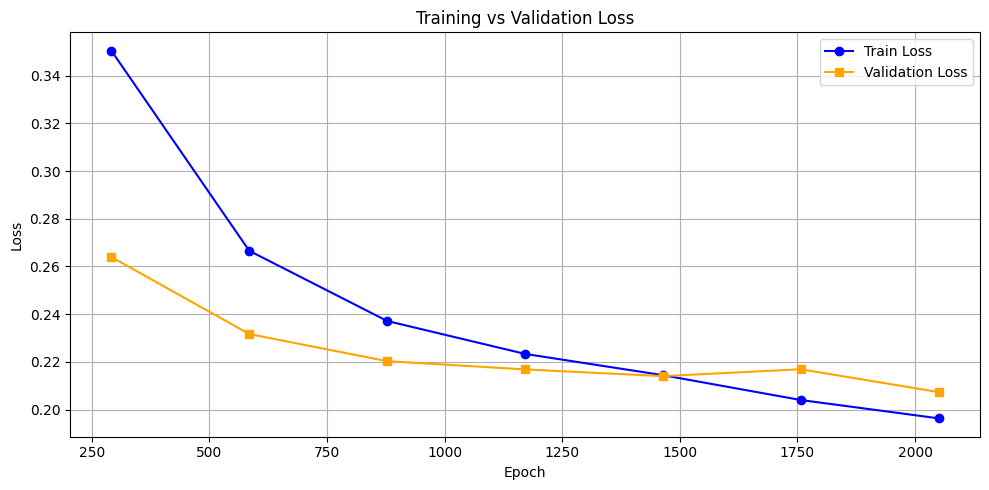

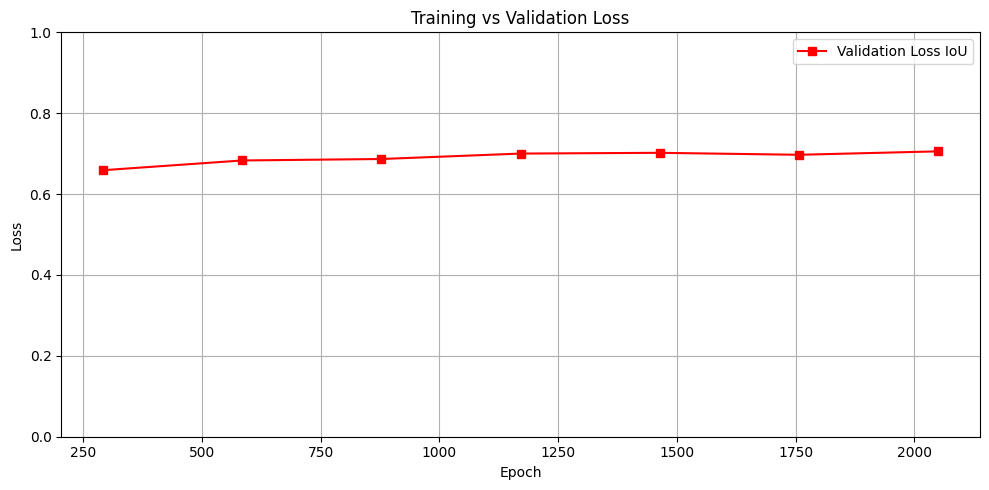

In [50]:
# TODO REMOVE THIS or make it cleaner
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

# Step 1: Point to your log directory
event_path = "lightning_logs/version_3/events.out.tfevents.1752880877.THINKPAD.22792.7"

# Load and parse event data
ea = event_accumulator.EventAccumulator(event_path)
ea.Reload()

# Extract scalar events
train_loss_events = ea.Scalars("train_loss")
val_loss_events = ea.Scalars("val_loss")
val_iou_loss_events = ea.Scalars("val_mIoU")

# Extract steps and values
train_steps = [e.step for e in train_loss_events]
train_values = [e.value for e in train_loss_events]

val_steps = [e.step for e in val_loss_events]
val_values = [e.value for e in val_loss_events]

val_iou_steps = [e.step for e in val_iou_loss_events]
val_iou_values = [e.value for e in val_iou_loss_events]

# Plot both losses
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_values, label="Train Loss", marker="o", color="blue")
plt.plot(val_steps, val_values, label="Validation Loss", marker="s", color="orange")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Also show IoU Loss
plt.figure(figsize=(10, 5))
plt.plot(val_iou_steps, val_iou_values, label="Validation Loss IoU", marker="s", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim((0,1))
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**TODO:** Describe the results in a few paragraphs.

## 2.4 Training Visualization + Evaluation

It is always good to visualize your training and some qualitative examples on top of the quantitative results obtained above. In this task you should:
1. Visualize model performance over the training epochs
2. Visualize some examples.

Briefly describe the results.

### 2.4.1 Training Visualization

Please visualize validation loss as well as validation performance over the epochs of your training. We recommend using the lighting `CSVLogger`. Plot the results.

In [ ]:
# Plot mIoU and loss over training epochs

**TODO:** Describe the results in a few paragraphs.

### 2.4.2 Qualitative Evaluation

Please visualize a few (at least 2) example outputs in the form: 1: Input Image 2: Reference Mask 3: Predicted Mask.


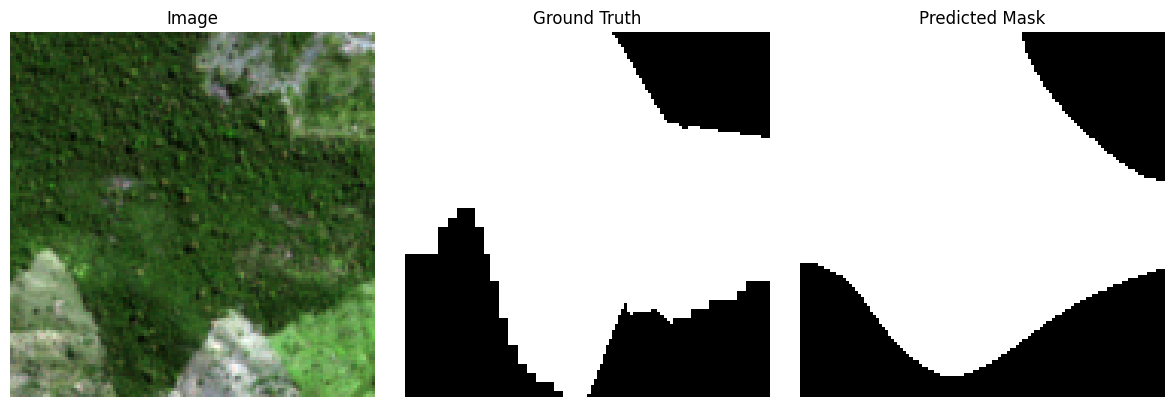

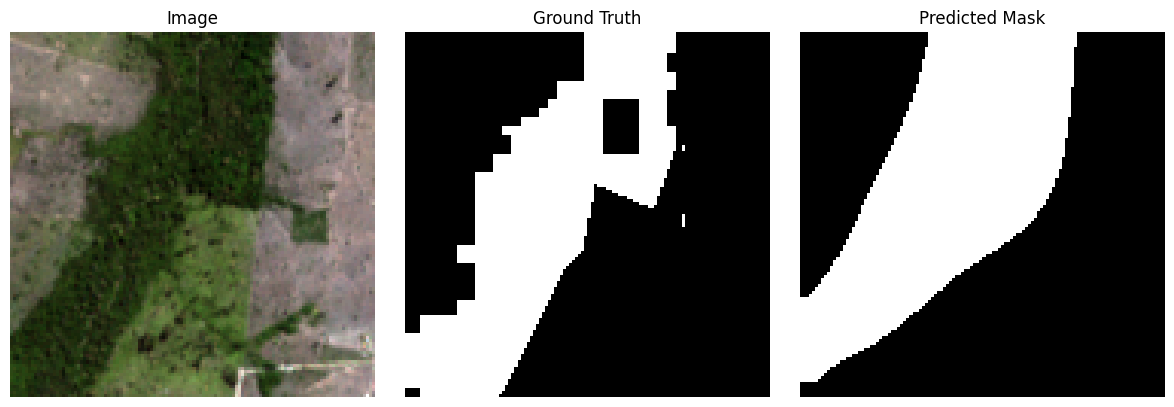

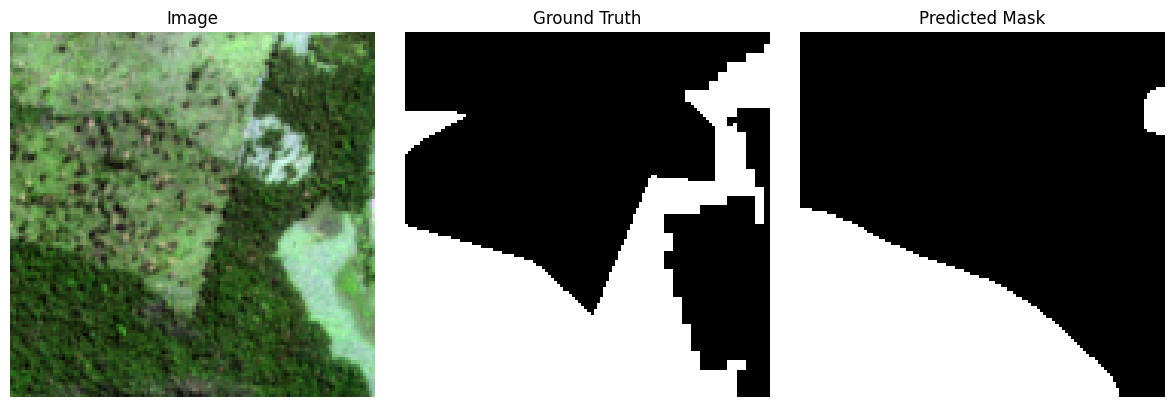

In [52]:
def show_image_mask_prediction(image, mask_gt, mask_pred):
    image = image.cpu().numpy()
    mask_gt = mask_gt.cpu().numpy().squeeze()
    mask_pred = mask_pred.cpu().numpy().squeeze()

    if image.dtype == 'object':
        image = image.astype(np.uint8)
    if mask_gt.dtype == 'object':
        mask_gt = mask_gt.astype(np.uint8)
    if mask_pred.dtype == 'object':
        mask_pred = mask_pred.astype(np.uint8)

    rgb = image[np.array((0, 1, 2)), :, :].astype(np.float32)
    eps = 1e-6
    for i in range(rgb.shape[0]):
        rgb[i] = (rgb[i] - rgb[i].min()) / (rgb[i].max() - rgb[i].min() + eps)
    rgb = np.transpose(rgb, (1, 2, 0))

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mask_pred, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def test_model_with_dataloader(model, dataloader):
    model.eval()
    device = model.device

    # One batch (batch_size x image x mask)
    data_iter = iter(dataloader)
    images, masks = next(data_iter)

    # Random index within batch
    idx = random.randint(0, images.size(0) - 1)

    image = images[idx].unsqueeze(0).to(device)
    mask_gt = masks[idx].to(device)

    with torch.no_grad():
        output = model(image)

    mask_pred = (torch.sigmoid(output) > 0.5).float()

    show_image_mask_prediction(image.squeeze(0), mask_gt, mask_pred.squeeze(0))


# -----------------------
# show the model in action

val_loader = dm.test_dataloader()
test_model_with_dataloader(model, val_loader)

val_loader = dm.test_dataloader()
test_model_with_dataloader(model, val_loader)

val_loader = dm.test_dataloader()
test_model_with_dataloader(model, val_loader)

**TODO:** Describe the results in a few paragraphs.